# 1. Objective and Setup

This notebook uses information from the Hidden Markov Model (HMM) to improve one-step-ahead volatility forecasts. At each step, only information available at that time is used. The forecasts will later be used for Value-at-Risk (VaR) backtesting.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import data_loader as dl
from src import preprocessing as pp
from src import garch
from src import features
from src.markov_model.hmm import HiddenMarkovModel as hmm
from sklearn.preprocessing import StandardScaler

In [2]:
# Download S&P 500 data from 2000-01-01 and compute daily log returns.
raw_data = dl.load_market_data()
market_data = pp.preprocess_market_data(raw_data)
vix = dl.load_market_data(ticker = "^VIX")
garch_output = garch.fit_garch(market_data["Return"]*100)

In [8]:
prices = market_data["Close"].astype(float)
momentum_20 = features.compute_momentum(prices, window=20).rename("Momentum_20")
vix_close = vix["Close"].astype(float).rename("VIX")

base_features = pd.concat(
    [
        momentum_20,
        vix_close
    ],
    axis=1
)

base_features = (base_features.replace([np.inf, -np.inf], np.nan).dropna().sort_index())

split_idx = int(len(base_features) * 0.7)

train_dates = base_features.index[:split_idx]
test_dates = base_features.index[split_idx:]
df_test = base_features.loc[test_dates].copy()

train_returns = market_data.loc[train_dates,"Return"].dropna()
training_garch_output = garch.fit_garch(train_returns * 100,distribution="t")
train_garch_vol = (training_garch_output.conditional_volatility / 100).rename("Conditional_Volatility")

df_train = pd.concat(
    [
        momentum_20.loc[train_dates],
        train_garch_vol,
        vix_close.loc[train_dates]
    ],
    axis=1
)

df_train = (df_train.replace([np.inf, -np.inf], np.nan).dropna().sort_index())

/var/folders/95/crxm_mbj7z314zvdmct7dj680000gn/T/ipykernel_34643/2288037569.py:5: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  base_features = pd.concat(


## 2. Forecasting Dataset

The final HMM uses 20-day momentum, GARCH conditional volatility, and VIX. The data is split chronologically into 70% training and 30% test data to preserve the time-series structure.

The features are standardized using a StandardScaler fitted only on the training data, preventing information from the test period from entering the model. A three-state Gaussian HMM with full covariance matrices is then fitted to the training sample.

The test period is reserved for out-of-sample one-step-ahead forecasting, where only information available at each forecast origin is used to avoid look-ahead bias.

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(df_train)

model = hmm(
    feature_matrix=X_train,
    states=3,
    covariance_type="full"
).fit()

## 3. Regime-Specific Volatility Characteristics

Before constructing the forecasting model, the return characteristics of the identified regimes are examined. Smoothed probabilities are used only for this in-sample analysis and are not used for out-of-sample forecasting.

In [5]:
train_probs = model.smooth_proba(X_train)
train_states = np.argmax(train_probs, axis=1)

regime_analysis = df_train.copy()

regime_analysis["Returns"] = market_data.loc[
    df_train.index,
    "Return"
]

regime_analysis["State"] = train_states

regime_stats = regime_analysis.groupby("State")["Returns"].agg([
    "count",
    "mean",
    "std",
    "min",
    "max"
])

display(regime_stats)

,count,mean,std,min,max
State,,,,,
0,2058,0.000608,0.006083,-0.024828,0.021596
1,707,-0.000645,0.023007,-0.094695,0.109572
2,1917,-0.000040,0.010853,-0.036581,0.038183


The regimes exhibit clearly different return distributions. State 0 represents the calm regime, with positive average returns and the lowest volatility. State 1 represents the stressed regime, with negative average returns and substantially higher volatility, while State 2 represents an intermediate regime. In particular, return volatility in the stressed regime is almost four times higher than in the calm regime. These differences motivate investigating whether HMM regime information can improve volatility forecasts.

## 4. Baseline GARCH Forecasting

A standard GARCH(1,1) model with Student-t innovations is used as the baseline volatility model. The model is initially estimated using only the training sample. One-step-ahead volatility forecasts are then done for the out-of-sample period using information available at each timestep. These forecasts provide the benchmark against which the regime-based model will later be evaluated. The formula for forecasting is: $\sigma^2_{t+1|t} = \omega + \alpha \epsilon^2_t + \beta \sigma^2_t$. The forecast depends on the most recent squared shock and conditional variance, both of which are known at time $t$.

### 4.1 Initial Model Estimation

Model fitted on training returns.

In [6]:
train_returns = market_data.loc[df_train.index,"Return"]

baseline_garch_output = garch.fit_garch(train_returns * 100, distribution="t")
baseline_garch_model = baseline_garch_output.result
params = baseline_garch_model.params

print(params)

alpha = params["alpha[1]"]
beta = params["beta[1]"]

print(f"\nVolatility persistence (alpha + beta): "f"{alpha + beta:.4f}")

mu          0.066023
omega       0.009430
alpha[1]    0.103171
beta[1]     0.894981
nu          6.536139
Name: params, dtype: float64

Volatility persistence (alpha + beta): 0.9982


#### Discussion

The baseline GARCH(1,1) model shows high volatility persistence, with $\alpha + \beta = 0.9982$. This means that changes in volatility tend to persist over time. The Student-t parameter of 6.54 also suggests that extreme returns occur more often than under a normal distribution.

### 4.2 Walking-Forward Volatility Forecasts

One-step-ahead volatility forecasts are generated in sequence throughout the test period. The GARCH conditional variance is updated each day as new with new returns, while the model parameters are re-estimated at the beginning of each month using an expanding historical window. This approach allows the model to adapt over time without requiring a full re-estimation every trading day.

In [9]:
history_returns = market_data.loc[df_train.index,"Return"].copy()

# Containers for the out-of-sample forecasts
forecast_dates = []
baseline_vol_forecasts = []

# Current model state
current_month = None
current_model = None

mu = None
omega = None
alpha = None
beta = None
variance_t = None
residual_t = None


for target_date in df_test.index:
    target_month = target_date.to_period("M")

    #refit each month
    if current_month != target_month:
        
        current_output = garch.fit_garch(history_returns * 100, distribution="t")
        current_model = current_output.result
        params = current_model.params

        mu = params["mu"]
        omega = params["omega"]
        alpha = params["alpha[1]"]
        beta = params["beta[1]"]
        
        variance_t = (current_output.conditional_volatility.iloc[-1] ** 2)
        last_return_pct = history_returns.iloc[-1] * 100
        residual_t = last_return_pct - mu
        
        current_month = target_month

    #forecast
    forecast_variance = garch.forecast_variance_one_step(omega, alpha, beta, residual_t, variance_t)
    forecast_vol_pct = np.sqrt(forecast_variance)

    forecast_vol = forecast_vol_pct / 100

    # Store forecast against the date it predicts
    forecast_dates.append(target_date)
    baseline_vol_forecasts.append(forecast_vol)

    realized_return = market_data.loc[target_date, "Return"]
    realized_return_pct = realized_return * 100

    # The forecast variance becomes today's conditional variance
    variance_t = forecast_variance

    # Update residual using the newly observed return
    residual_t = realized_return_pct - mu

    # Add the newly observed return to the expanding history
    history_returns.loc[target_date] = realized_return


In [10]:
baseline_forecasts = pd.DataFrame(
    {
        "Baseline_Volatility": baseline_vol_forecasts,
        "Actual_Return": market_data.loc[
            forecast_dates,
            "Return"
        ].values
    },
    index=forecast_dates
)

baseline_forecasts.index.name = "Date"

display(baseline_forecasts.head())

,Baseline_Volatility,Actual_Return
Date,,
2018-09-12,0.004806,0.000357
2018-09-13,0.004650,0.005268
2018-09-14,0.004742,0.000275
2018-09-17,0.004592,-0.005585
2018-09-18,0.004882,0.005355


### 4.3 Baseline Forecast Results

The walking-forward procedure produces a one-day-ahead volatility forecast for each observation in the test period. The forecasts are first examined to verify that the model responds reasonably to changes in market volatility before introducing regime information.

,Baseline_Volatility,Actual_Return
count,2007.000000,2007.000000
mean,0.010776,0.000487
std,0.006601,0.012342
min,0.004308,-0.127652
25%,0.007159,-0.004474
50%,0.009035,0.000866
75%,0.012361,0.006510
max,0.068796,0.090895


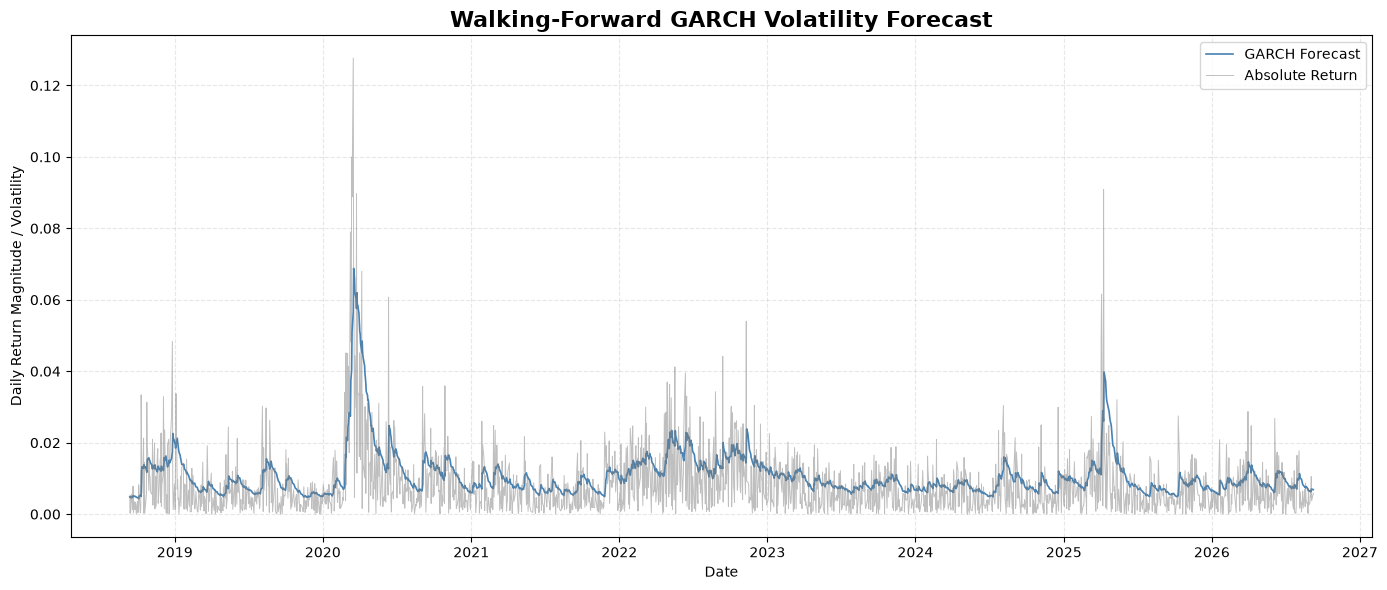

In [11]:
display(
    baseline_forecasts[
        ["Baseline_Volatility", "Actual_Return"]
    ].describe()
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    baseline_forecasts.index,
    baseline_forecasts["Baseline_Volatility"],
    color="steelblue",
    linewidth=1.2,
    label="GARCH Forecast"
)

ax.plot(
    baseline_forecasts.index,
    baseline_forecasts["Actual_Return"].abs(),
    color="grey",
    linewidth=0.7,
    alpha=0.5,
    label="Absolute Return"
)

ax.set_title(
    "Walking-Forward GARCH Volatility Forecast",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Return Magnitude / Volatility")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Discussion 

The GARCH forecast changes with market risk over time. Large market movements are usually followed by higher forecast volatility, while volatility gradually falls during calmer periods. The forecast is smoother than absolute returns because GARCH estimates the general level of volatility rather than predicting each daily movement.

Overall, the baseline model reacts well to changing market conditions and provides a useful benchmark for testing whether HMM regime information can improve the volatility forecast.

## 5. Filtered HMM Probabilities

In the previous notebook, smoothed probabilities were used to analyze the identified market regimes. Smoothed probabilities use the full dataset which includes observations after time $t$, hence they are not suitable for real-time forecasting. For the walking-forward forecast instead filtered probabilities are used. These estimate the probability of each regime using only information available up to the current time. This avoids using future information when estimating the current market regime.

### 5.1 Construct Out-of-Sample HMM Features

Filtered probabilities are computed sequentially using the forward algorithm. At each date $t$ the HMM only uses observations available up to that date. This gives the estimated probability of being in each regime at the current time. The out-of-sample HMM features are constructed using only information available at each forecast origin. The model uses 20-day momentum, VIX, and the most recent GARCH volatility estimate. The GARCH volatility series is shifted by one day so that the HMM does not use the volatility forecast for the target date itself.

In [12]:
test_momentum = momentum_20.loc[
    df_test.index
].copy()

test_vix = vix_close.loc[
    df_test.index
].copy()

# Use the most recent GARCH volatility estimate available
test_garch_vol = (baseline_forecasts["Baseline_Volatility"] .shift(1).rename("Conditional_Volatility"))

oos_hmm_features = pd.concat(
    [
        test_momentum.rename("Momentum_20"),
        test_garch_vol,
        test_vix.rename("VIX")
    ],
    axis=1
)

oos_hmm_features = (
    oos_hmm_features
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_index()
)


### 5.2 Compute Filtered Probabilities

The out-of-sample features are standardized using the scaler fitted on the training data. The HMM then estimates the probability of being in each market regime at every date using only information available up to that point.

In [13]:
X_oos = scaler.transform(oos_hmm_features)

filtered_probs = model.filter_proba(X_oos)

filtered_probs_df = pd.DataFrame(
    filtered_probs,
    index=oos_hmm_features.index,
    columns=["State_0", "State_1", "State_2"]
)

np.allclose(filtered_probs_df.sum(axis=1), 1.0)
filtered_probs_df.head()


,State_0,State_1,State_2
Date,,,
2018-09-13,6.846004e-11,1.916181e-13,1.000000
2018-09-14,6.002787e-01,6.411884e-04,0.399080
2018-09-17,9.756054e-01,3.702002e-05,0.024358
2018-09-18,9.994072e-01,2.756418e-06,0.000590
2018-09-19,9.999398e-01,7.631284e-07,0.000059


## 6. Next-Day Regime Probabilities

The filtered probabilities describe the probability of each market regime at the current date. To forecast the regime for the next trading day the filtered probabilities are combined with the HMM transition matrix. This produces the probability of each regime for the next period. The formula $P(S_{t+1}|X_{1:t})= P(S_{t}|X_{1:t}) A$ is hence used to produce the next-day regime dataframe. 

### 6.1 Compute Next-Day Probabilities

In [14]:
next_state_probs = (filtered_probs @ model.transition_matrix)

next_state_probs_df = pd.DataFrame(
    next_state_probs,
    index=oos_hmm_features.index,
    columns=["State_0", "State_1", "State_2"]
)

np.allclose(
    next_state_probs_df.sum(axis=1),
    1.0
)

True

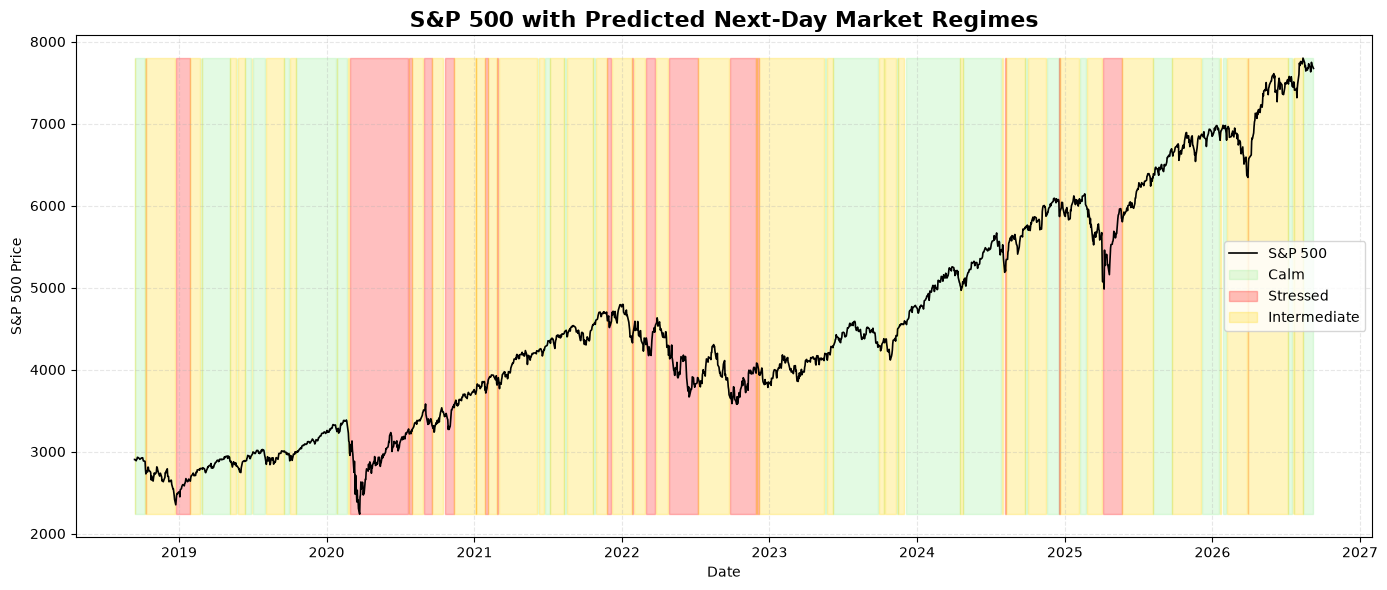

In [15]:
next_regime = np.argmax(next_state_probs, axis=1)
next_prices = market_data.loc[next_state_probs_df.index,"Close"]

state_labels = {
    0: "Calm",
    1: "Stressed",
    2: "Intermediate"
}

state_colors = {
    0: "lightgreen",  
    1: "red",         
    2: "gold"      
}

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    next_prices.index,
    next_prices,
    color="black",
    linewidth=1.2,
    label="S&P 500"
)

for state in range(3):
    mask = next_regime == state

    ax.fill_between(
        next_prices.index,
        next_prices.min(),
        next_prices.max(),
        where=mask,
        color=state_colors[state],
        alpha=0.25,
        label=state_labels[state]
    )

ax.set_title(
    "S&P 500 with Predicted Next-Day Market Regimes",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("S&P 500 Price")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Discussion.

The predicted regimes show a clear relationship with market conditions. Stressed periods tend to appear during larger market declines, while calm periods are more common during stable or upwards trending markets. Intermediate market regime dominates the time period which reasonable since the period 2020-2026 have had a lot of uncertainty in the markets. The model also switches between regimes during shorter periods of uncertainty, showing that the HMM reacts to changes in market conditions. Overall the next-day regime predictions seems reasonable and can now be used with the baseline GARCH volatility forecast.

## 7. Regime-Aware Volatility Forecas

The baseline GARCH model captures changes in volatility over time and the HMM provides information about the expected market regime. This section combines these two models to construct a regime-aware one-step-ahead volatility forecast.

### 7.1 Regime Volatility Levels

The three HMM regimes have different levels of return volatility. The volatility of each regime is estimated using the standard deviation of returns in the training data. Realized returns are used instead of GARCH conditional volatility because they directly show how much returns actually varied within each regime. 

In [16]:
regime_volatility = regime_stats["std"]

for state, vol in regime_volatility.items():
    print(f"{state_labels[state]}: {vol:.2%}")

Calm: 0.61%
Stressed: 2.30%
Intermediate: 1.09%


### 7.2 Regime-Implied Volatility

The next-day regime probabilities are combined with the volatility level of each regime to create a single expected volatility. In other words, instead of selecting only the most likely regime, all regime probabilities are used.

In [17]:
regime_variances = regime_volatility.values ** 2

regime_implied_variance = (next_state_probs_df.values @ regime_variances)

regime_implied_volatility = np.sqrt(regime_implied_variance)

regime_implied_volatility = pd.Series(
    regime_implied_volatility,
    index=next_state_probs_df.index,
    name="Regime_Implied_Volatility"
)

regime_implied_volatility.head()

Date
2018-09-13    0.010923
2018-09-14    0.008418
2018-09-17    0.006339
2018-09-18    0.006183
2018-09-19    0.006180
Name: Regime_Implied_Volatility, dtype: float64

### 7.3 Regime Adjustment

The baseline GARCH model provides the next-day volatility forecast. The HMM is then used to adjust this forecast depending on whether the market is expected to move toward a more or less volatile regime. The adjustment factor compares the expected regime volatility for the next day with the current regime volatility with the following formula: $A_{t+1} = \frac{\hat{\sigma}^{HMM}_{t+1|t}}{\hat{\sigma}^{HMM}_{t|t}}$.

If the factor is above one then the HMM indicates higher regime risk for the next day. If it is below one it instead indicates lower regime risk.
The regime-aware forecast is then: $\hat{\sigma}^{RA}_{t+1|t} = \hat{\sigma}^{GARCH}_{t+1|t} A_{t+1}$. This allows the HMM to adjust the GARCH forecast based on expected changes in the market regime.

In [18]:
current_regime_variance = (filtered_probs_df.values @ regime_variances)

current_regime_volatility = np.sqrt(current_regime_variance)

current_regime_volatility = pd.Series(
    current_regime_volatility,
    index=filtered_probs_df.index,
    name="Current_Regime_Implied_Volatility"
)

regime_adjustment = (regime_implied_volatility / current_regime_volatility)

regime_adjustment.name = "Regime_Adjustment"

regime_adjustment.describe()

count    2006.000000
mean        1.006560
std         0.007444
min         0.992719
25%         1.006254
50%         1.006455
75%         1.014680
max         1.015897
Name: Regime_Adjustment, dtype: float64

### 7.4 Regime-Aware GARCH Forecast

In [19]:
baseline_aligned = baseline_forecasts.loc[
    regime_adjustment.index,
    "Baseline_Volatility"
]

regime_aware_volatility = (baseline_aligned * regime_adjustment)

regime_aware_volatility.name = "Regime_Aware_Volatility"

volatility_forecasts = pd.DataFrame(
    {
        "Baseline_GARCH": baseline_aligned,
        "Regime_Adjustment": regime_adjustment,
        "Regime_Aware_GARCH": regime_aware_volatility,
        "Actual_Return": market_data.loc[
            regime_adjustment.index,
            "Return"
        ]
    }
)

volatility_forecasts.index.name = "Date"

display(volatility_forecasts.head())

,Baseline_GARCH,Regime_Adjustment,Regime_Aware_GARCH,Actual_Return
Date,,,,
2018-09-13,0.004650,1.006468,0.004680,0.005268
2018-09-14,0.004742,1.009423,0.004787,0.000275
2018-09-17,0.004592,1.015197,0.004662,-0.005585
2018-09-18,0.004882,1.015881,0.004960,0.005355
2018-09-19,0.004955,1.015897,0.005034,0.001252


### 7.5 Forecast Comparison

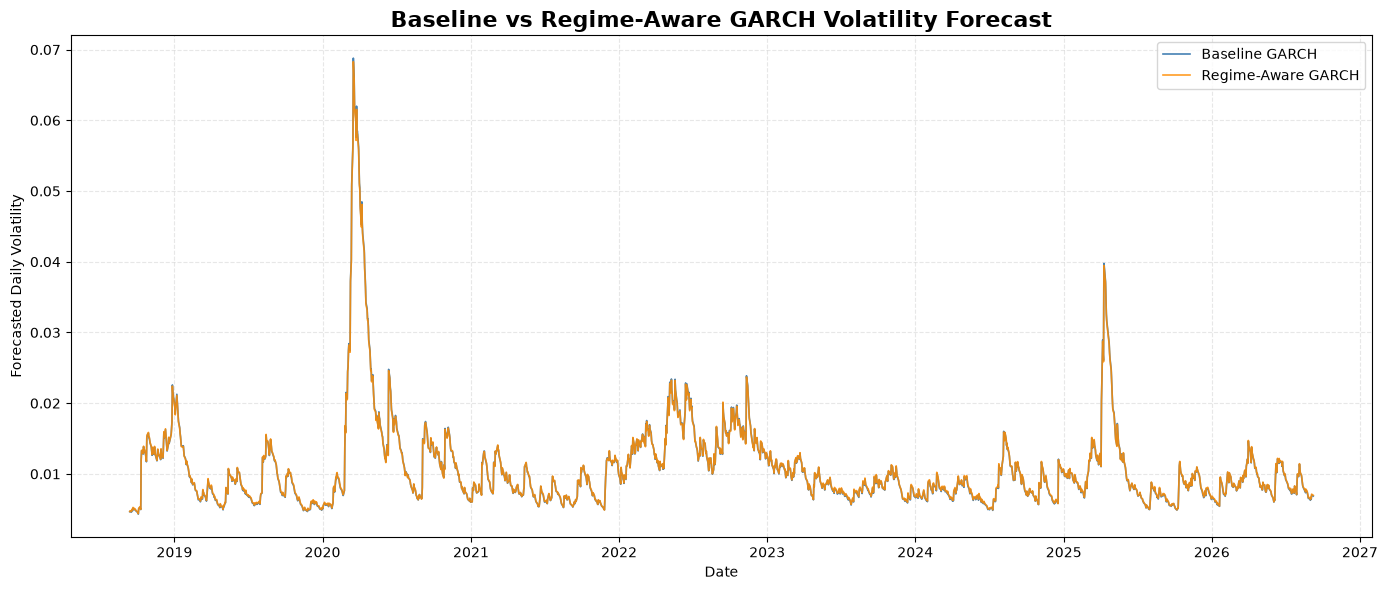

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    volatility_forecasts.index,
    volatility_forecasts["Baseline_GARCH"],
    color="steelblue",
    linewidth=1.2,
    label="Baseline GARCH"
)

ax.plot(
    volatility_forecasts.index,
    volatility_forecasts["Regime_Aware_GARCH"],
    color="darkorange",
    linewidth=1.2,
    alpha=0.85,
    label="Regime-Aware GARCH"
)

ax.set_title(
    "Baseline vs Regime-Aware GARCH Volatility Forecast",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Forecasted Daily Volatility")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Discussion

The regime-aware and baseline GARCH forecasts are very similar throughout the test period. This is expected because the HMM regimes are highly persistent, resulting in relatively small changes between the current and predicted next-day regime probabilities.

As a result, the regime adjustment factor remains close to one and only makes small changes to the baseline GARCH forecast. Whether these adjustments improve risk forecasts will be evaluated through VaR backtesting in the next notebook.

## 8. Leakage and Sanity Checks

Multiple checks are performed to make sure that the out-of-sample forecasting does not use future information.

The initial GARCH model used to construct the HMM training features is estimated only on the training period. The StandardScaler and HMM are also fitted only on the training sample.

During the test period the GARCH forecasts are generated in a walking-forward setting. Realized returns are added to the history after the corresponding forecast has been generated. Filtered HMM probabilities are used for out-of-sample regime estimation and smoothed probabilities are only used in the in-sample regime analysis.

In [21]:
# Train/test order
assert train_dates.max() < test_dates.min()

# Forecast alignment
assert volatility_forecasts.index.equals(regime_adjustment.index)

# Positive volatility forecasts
assert (volatility_forecasts["Baseline_GARCH"] > 0).all()
assert (volatility_forecasts["Regime_Aware_GARCH"] > 0).all()

# No missing values
assert volatility_forecasts.notna().all().all()

# Probabilities sum to one
assert np.allclose(filtered_probs_df.sum(axis=1), 1.0)
assert np.allclose(next_state_probs_df.sum(axis=1), 1.0)

print("All leakage and sanity checks passed.")

All leakage and sanity checks passed.


## 9. Conclusion

This notebook developed a regime-aware volatility forecasting model by combining a standard GARCH model with regime information from the HMM. The HMM identified three distinct and persistent market regimes: calm, intermediate, and stressed. During the out-of-sample period the filtered regime probabilities and the transition matrix were used to predict the next-day regime probabilities without using future information.

These probabilities were then used to adjust the baseline GARCH forecast based on expected changes in regime risk. Since the identified regimes are highly persistent, the adjustments are relatively small and the regime-aware forecasts remain close to the baseline GARCH forecasts. The next notebook evaluates whether these regime adjustments improve Value-at-Risk forecasts through out-of-sample backtesting.